# MATH GR5360 Final Project — Master Pipeline

One-click amalgamated notebook. It imports the shared engine, runs the full diagnostic pipeline, executes the walk-forward engine, computes the OOS and modal full-sample metrics, and leaves all major artifacts in memory for presentation or C-port verification.


In [2]:
MARKET_SELECT = 'TY'
QUICK_TEST = True
WALKFORWARD_MODE = 'dynamic'
RUN_EXTENDED_SURFACE = False

In [3]:
from pathlib import Path
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

CWD = Path.cwd().resolve()
PROJECT_ROOT = CWD if (CWD / 'mafn_engine').exists() else CWD.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from mafn_engine import (
    COLUMBIA_CORE,
    COLUMBIA_DIVERGING,
    COLUMBIA_NAVY,
    COLUMBIA_RED,
    COLUMBIA_WARM,
    apply_columbia_theme,
    default_mr_grid,
    default_tf_grid,
    drawdown_family,
    get_market,
    load_ohlc,
    performance_from_ledger,
    prepare_analysis_frame,
    run_backtest,
    run_diagnostics,
    run_mr_backtest,
    run_tf_backtest,
    select_modal_configuration,
    validate_ohlc,
    walk_forward,
    walk_forward_surface,
)

apply_columbia_theme()
MARKET = get_market(MARKET_SELECT)
DATA_DIR = str(PROJECT_ROOT / 'data')
print(f"Market: {MARKET.ticker} - {MARKET.name} ({MARKET.exchange})")
print(f"PV=${MARKET.PV:,}  Slippage=${MARKET.slpg}  E0=${MARKET.E0:,.0f}")

Market: TY - 10-Year Treasury (CBOT-CME)
PV=$1,000  Slippage=$18.625  E0=$100,000


In [4]:
DEFAULT_T_VALUES = [1, 2, 3, 4, 5, 6]
DEFAULT_TAU_VALUES = [1, 2, 3, 4]


def _grid_signature(grid: dict[str, np.ndarray]) -> tuple[tuple[str, tuple[float, ...]], ...]:
    signature = []
    for key in sorted(grid):
        values = []
        for value in np.asarray(grid[key]).tolist():
            if isinstance(value, (int, np.integer)):
                values.append(int(value))
            else:
                values.append(float(value))
        signature.append((key, tuple(values)))
    return tuple(signature)


def ensure_analysis_state(force: bool = False) -> None:
    global MARKET, full_df, validation, analysis_df, tf_grid, mr_grid, _analysis_market

    MARKET = get_market(MARKET_SELECT)
    if force or globals().get('_analysis_market') != MARKET_SELECT or 'analysis_df' not in globals():
        full_df = load_ohlc(DATA_DIR, MARKET_SELECT, fallback_synthetic=False)
        validation = validate_ohlc(full_df)
        analysis_df = prepare_analysis_frame(full_df, MARKET_SELECT)
        _analysis_market = MARKET_SELECT

    tf_grid = default_tf_grid(MARKET_SELECT, quick=QUICK_TEST)
    mr_grid = default_mr_grid(MARKET_SELECT, quick=QUICK_TEST)


def ensure_diagnostics_state(force: bool = False) -> None:
    global diagnostics_bundle, vr_price_df, regime_table, regime_choice, _diagnostics_market

    ensure_analysis_state(force=force)
    if force or globals().get('_diagnostics_market') != MARKET_SELECT or 'diagnostics_bundle' not in globals():
        diagnostics_bundle = run_diagnostics(analysis_df, MARKET_SELECT)
        vr_price_df = diagnostics_bundle['vr_price_df']
        regime_table = diagnostics_bundle['regime_table']
        regime_choice = diagnostics_bundle['regime_choice']
        _diagnostics_market = MARKET_SELECT


def ensure_walkforward_state(force: bool = False) -> None:
    global wf_bundle, wf_params, wf_equity, wf_ledger, wf_results, _wf_signature

    ensure_analysis_state(force=force)
    signature = (
        MARKET_SELECT,
        WALKFORWARD_MODE,
        bool(QUICK_TEST),
        4,
        1,
        _grid_signature(tf_grid),
        _grid_signature(mr_grid),
    )

    if force or globals().get('_wf_signature') != signature or 'wf_bundle' not in globals():
        wf_bundle = walk_forward(
            analysis_df,
            MARKET_SELECT,
            mode=WALKFORWARD_MODE,
            tf_grid=tf_grid,
            mr_grid=mr_grid,
            T_years=4,
            tau_quarters=1,
            quick=QUICK_TEST,
            verbose=True,
        )
        _wf_signature = signature

    wf_params = wf_bundle['params']
    wf_equity = wf_bundle['equity']
    wf_ledger = wf_bundle['ledger']
    wf_results = wf_params


def _fallback_modal_config() -> dict[str, object]:
    ensure_diagnostics_state()
    modal = {'family': regime_choice['family']}
    if modal['family'] == 'tf':
        modal.update({'L': int(tf_grid['L'][0]), 'S': float(tf_grid['S'][0])})
    else:
        modal.update(
            {
                'N1': float(mr_grid['N1'][0]),
                'N2': float(mr_grid['N2'][0]),
                'VolLen': int(mr_grid['VolLen'][0]),
                'MALen': int(mr_grid['MALen'][0]),
                'StpPct': float(mr_grid['StpPct'][0]),
            }
        )
    return modal


def ensure_full_sample_state(force: bool = False) -> None:
    global modal_cfg, full_sample_result, oos_metrics, full_sample_metrics, _full_sample_signature

    ensure_walkforward_state(force=force)
    ensure_diagnostics_state(force=force)
    candidate = select_modal_configuration(wf_params)
    if candidate is None:
        candidate = _fallback_modal_config()

    signature = (MARKET_SELECT, tuple(sorted(candidate.items())))
    if force or globals().get('_full_sample_signature') != signature or 'full_sample_result' not in globals():
        modal_cfg = dict(candidate)
        full_sample_result = run_backtest(
            analysis_df,
            MARKET_SELECT,
            modal_cfg['family'],
            {k: v for k, v in modal_cfg.items() if k != 'family'},
        )
        oos_metrics = performance_from_ledger(
            wf_ledger,
            wf_equity['OOS_Equity'].values if len(wf_equity) else np.array([MARKET.E0]),
            MARKET_SELECT,
        )
        full_sample_metrics = performance_from_ledger(
            full_sample_result['Ledger'],
            full_sample_result['Equity'],
            MARKET_SELECT,
        )
        _full_sample_signature = signature


ensure_diagnostics_state(force=True)
print(validation)
print(regime_choice)
regime_table.head()

✓ Loaded TY from /Users/nigelli/Desktop/Columbia MAFN/26Spring/MATH5360/Final Project/MATH5360_Final_Project/data/TY-5minHLV.csv
{'n_bars': 863887, 'start': Timestamp('1983-01-03 08:05:00'), 'end': Timestamp('2026-04-10 14:00:00'), 'years': 43.266255989048595, 'issues': [], 'is_valid': True}
{'family': 'tf', 'tf_votes': 7, 'mr_votes': 4, 'median_vr_shift': -0.06864006379765347, 'median_pr_rho': 0.24545454545454545, 'reason': 'significant-vote majority', 'ambiguous': False}


,time_scale,k,VR,VR_Z2_robust,VR_p2,VR_sig,VR_pattern,push_scale,PR_rho_mean,PR_rho_sig_any,Recommendation
0,10min,2,0.957058,-0.022650,0.981930,False,mean_revert,NaN,NaN,NaN,TF-baseline (no rejection)
1,20min,4,0.938027,-0.017345,0.986161,False,mean_revert,NaN,NaN,NaN,TF-baseline (no rejection)
2,40min,8,0.931002,-0.013010,0.989620,False,mean_revert,NaN,NaN,NaN,TF-baseline (no rejection)
3,1.0hr,12,0.931544,-0.010708,0.991456,False,mean_revert,1.0hr,0.393506,True,TF-baseline (no rejection)
4,2.0hr,24,0.931175,-0.008131,0.993512,False,mean_revert,2.0hr,0.280519,True,TF-baseline (no rejection)


In [5]:
ensure_full_sample_state(force=True)

print()
print('MASTER SUMMARY')
print('-' * 72)
print(f"Periods: {len(wf_params)}  |  OOS ledger rows: {len(wf_ledger)}")
print(f"Modal config: {modal_cfg}")
pd.DataFrame([oos_metrics, full_sample_metrics], index=['OOS', 'Full Sample'])

✓ Loaded TY from /Users/nigelli/Desktop/Columbia MAFN/26Spring/MATH5360/Final Project/MATH5360_Final_Project/data/TY-5minHLV.csv
Walk-Forward [TY] mode=dynamic: IS=4yr (80,640 bars), OOS=1Q (5,040 bars)
  P1 TF IS_obj=+7.592 OOS_obj=+2.079 votes(tf=19, mr=0)
  P2 TF IS_obj=+8.640 OOS_obj=+1.045 votes(tf=20, mr=0)
  P3 TF IS_obj=+9.273 OOS_obj=+0.501 votes(tf=15, mr=0)
  P4 TF IS_obj=+9.006 OOS_obj=-0.614 votes(tf=16, mr=0)
  P5 TF IS_obj=+9.831 OOS_obj=-0.624 votes(tf=13, mr=0)
  P6 TF IS_obj=+8.669 OOS_obj=-0.799 votes(tf=11, mr=1)
  P7 TF IS_obj=+7.125 OOS_obj=+0.927 votes(tf=12, mr=0)
  P8 TF IS_obj=+6.800 OOS_obj=+0.911 votes(tf=6, mr=0)
  P9 TF IS_obj=+7.571 OOS_obj=+0.000 votes(tf=5, mr=0)
  P10 TF IS_obj=+6.134 OOS_obj=-0.921 votes(tf=4, mr=1)
  P11 TF IS_obj=+5.540 OOS_obj=+0.521 votes(tf=5, mr=0)
  P12 TF IS_obj=+5.099 OOS_obj=-0.358 votes(tf=5, mr=0)
  P13 TF IS_obj=+3.116 OOS_obj=-0.343 votes(tf=3, mr=1)
  P14 MR IS_obj=-0.999 OOS_obj=-0.975 votes(tf=0, mr=3)
  P15 MR IS_obj

,Total Profit,Return %,Ann. Return %,Ann. Volatility %,Sharpe Ratio,Max Drawdown $,Max Drawdown %,Avg Drawdown $,CDD (α=0.05) $,DD Duration (bars),...,Total Trades,Win Rate %,Avg Winner $,Avg Loser $,Win/Loss Ratio,Profit Factor,Gross Profit $,Gross Loss $,Avg Trade PnL $,Avg Duration (bars)
OOS,-1.399238e+06,-1399.237724,46.306348,168.667936,0.274542,1.405547e+06,1322.516342,436285.305924,1.355122e+06,760382,...,24900,65.546185,49.834280,-265.335597,0.187816,0.357308,813345.289222,2.276314e+06,-58.753767,28.624378
Full Sample,1.050979e+05,105.097937,1.795121,4.420552,0.406085,2.890988e+04,13.809470,7412.080339,2.458103e+04,321048,...,248,43.145161,2792.315421,-1377.095745,2.027684,1.538739,298777.750000,1.941705e+05,421.803427,3346.544355


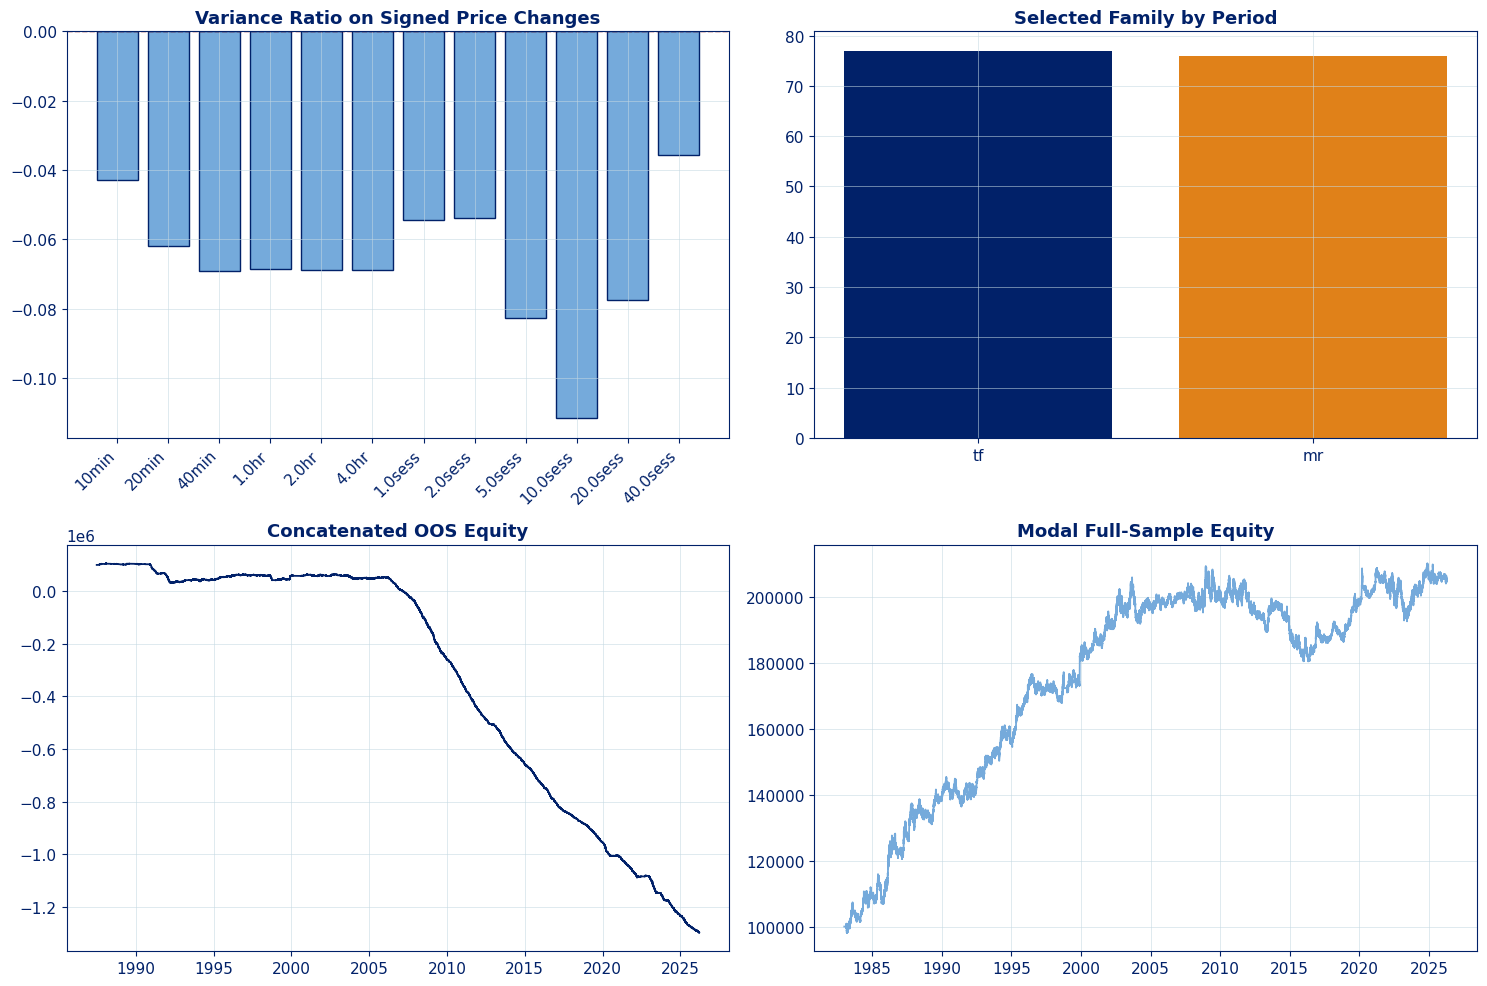

In [6]:
ensure_full_sample_state()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].bar(range(len(vr_price_df)), vr_price_df['VR'] - 1.0, color=COLUMBIA_CORE, edgecolor=COLUMBIA_NAVY)
axes[0, 0].axhline(0.0, color=COLUMBIA_RED, linestyle='--', linewidth=1)
axes[0, 0].set_xticks(range(len(vr_price_df)))
axes[0, 0].set_xticklabels(vr_price_df['time_scale'], rotation=45, ha='right')
axes[0, 0].set_title('Variance Ratio on Signed Price Changes')

fam_counts = wf_params['Family'].value_counts().reindex(['tf', 'mr']).fillna(0) if len(wf_params) else pd.Series({'tf': 0, 'mr': 0})
axes[0, 1].bar(fam_counts.index, fam_counts.values, color=[COLUMBIA_NAVY, COLUMBIA_WARM])
axes[0, 1].set_title('Selected Family by Period')

if len(wf_equity):
    axes[1, 0].plot(wf_equity.index, wf_equity['OOS_Equity'], color=COLUMBIA_NAVY)
    axes[1, 0].set_title('Concatenated OOS Equity')
else:
    axes[1, 0].text(0.5, 0.5, 'No OOS equity generated', ha='center', va='center')
    axes[1, 0].set_axis_off()

axes[1, 1].plot(analysis_df.index, full_sample_result['Equity'], color=COLUMBIA_CORE)
axes[1, 1].set_title('Modal Full-Sample Equity')

plt.tight_layout()
plt.show()

In [7]:
if RUN_EXTENDED_SURFACE:
    ensure_analysis_state()
    surface_df = walk_forward_surface(
        analysis_df,
        MARKET_SELECT,
        mode=WALKFORWARD_MODE,
        tf_grid=tf_grid,
        mr_grid=mr_grid,
        T_values=DEFAULT_T_VALUES,
        tau_values=DEFAULT_TAU_VALUES,
        quick=QUICK_TEST,
        verbose=False,
    )
    surface_valid = surface_df[~surface_df['error']].copy()
    surface_valid